In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from experiments import run_channel_noise_experiment
from encryption import run_secure_message_exchange

In [2]:
noise_probabilities = np.linspace(0, 0.20, 11)

df = run_channel_noise_experiment(
    n=5000,
    noise_probabilities=noise_probabilities,
    trials_per_rate=20,
    eve_intercept_prob=0.0
)

df

,channel_noise_probability,eve_interception_rate,average_qber,std_qber,trials_per_rate,qubits_per_trial
0,0.00,0.0,0.000000,0.000000,20,5000
1,0.02,0.0,0.020290,0.002716,20,5000
2,0.04,0.0,0.039674,0.004092,20,5000
3,0.06,0.0,0.061551,0.003772,20,5000
4,0.08,0.0,0.081058,0.005379,20,5000
5,0.10,0.0,0.101434,0.005214,20,5000
6,0.12,0.0,0.117904,0.005113,20,5000
7,0.14,0.0,0.140703,0.005449,20,5000
8,0.16,0.0,0.160568,0.006274,20,5000
9,0.18,0.0,0.183243,0.006356,20,5000


In [3]:
df.to_csv("../results/channel_noise_experiment_results.csv", index=False)

print("Saved results to ../results/channel_noise_experiment_results.csv")

Saved results to ../results/channel_noise_experiment_results.csv


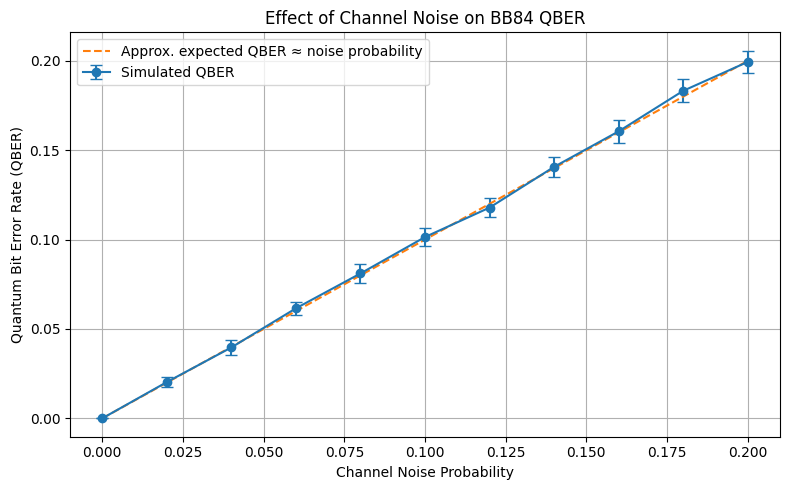

In [4]:
plt.figure(figsize=(8, 5))

plt.errorbar(
    df["channel_noise_probability"],
    df["average_qber"],
    yerr=df["std_qber"],
    marker="o",
    capsize=4,
    label="Simulated QBER"
)

plt.plot(
    df["channel_noise_probability"],
    df["channel_noise_probability"],
    linestyle="--",
    label="Approx. expected QBER ≈ noise probability"
)

plt.xlabel("Channel Noise Probability")
plt.ylabel("Quantum Bit Error Rate (QBER)")
plt.title("Effect of Channel Noise on BB84 QBER")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/qber_vs_channel_noise.png", dpi=300)
plt.show()

In [5]:
result = run_secure_message_exchange(
    message="Hello quantum world",
    n_qubits=10000,
    eve_intercept_prob=0.0,
    channel_noise_prob=0.03,
    qber_threshold=0.11,
    use_error_correction=True,
    error_correction_block_size=16,
    error_correction_passes=7,
    use_privacy_amplification=True,
    privacy_compression_ratio=0.5
)

print("Status:", result["status"])
print("Reason:", result["reason"])
print("QBER:", result["qber"])
print("Channel noise probability:", result["channel_noise_prob"])
print("Raw mismatches:", result["raw_mismatches"])
print("Final mismatches:", result["final_mismatches"])
print("Decrypted message:", result["decrypted_message"])

Status: success
Reason: Message encrypted and decrypted successfully.
QBER: 0.03020604120824165
Channel noise probability: 0.03
Raw mismatches: 151
Final mismatches: 0
Decrypted message: Hello quantum world


# Channel Noise Simulation

This notebook studies how normal channel noise affects BB84 communication.

Earlier experiments focused on Eve's intercept-resend attack. This version adds a separate channel noise parameter, allowing the simulation to compare errors caused by an attacker with errors caused by a noisy channel.

In this simplified model, channel noise flips transmitted bits with a selected probability. As the noise probability increases, the QBER also increases.